In [3]:
import pandas as pd

df = pd.read_csv("walmart_sales_raw_data.csv")

df.head()

,Date,Time_of_Purchase,Branch,City,Region,Product_Line,Customer_Type,Sales_Channel,Quantity,Unit_Price,Discount,Revenue,Profit,Payment_Method,Customer_Rating
0,2025-01-03,09:29:49,B,Chicago,Midwest,Health & Beauty,Normal,Online,9,165.22,0.07,1382.8914,152.22,Cash,8.1
1,2024-07-28,10:08:36,A,New York,East,Sports,Normal,In-store,2,551.32,0.18,904.1648,170.44,Cash,4.9
2,2024-06-27,18:36:27,B,Chicago,Midwest,Health & Beauty,Member,Online,3,41.41,0.19,100.6263,8.29,Credit Card,7.7
3,2024-09-22,16:24:11,C,San Francisco,West,Electronics,Normal,In-store,2,35.76,0.16,60.0768,11.39,Credit Card,8.9
4,2023-10-18,17:15:13,A,New York,East,Health & Beauty,Normal,In-store,9,526.44,0.07,4406.3028,468.21,Gift Card,9.1


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              1300 non-null   object 
 1   Time_of_Purchase  1300 non-null   object 
 2   Branch            1300 non-null   object 
 3   City              1300 non-null   object 
 4   Region            1300 non-null   object 
 5   Product_Line      1300 non-null   object 
 6   Customer_Type     1300 non-null   object 
 7   Sales_Channel     1300 non-null   object 
 8   Quantity          1300 non-null   int64  
 9   Unit_Price        1300 non-null   float64
 10  Discount          1300 non-null   float64
 11  Revenue           1300 non-null   float64
 12  Profit            1300 non-null   float64
 13  Payment_Method    1300 non-null   object 
 14  Customer_Rating   1300 non-null   float64
dtypes: float64(5), int64(1), object(9)
memory usage: 152.5+ KB


,Quantity,Unit_Price,Discount,Revenue,Profit,Customer_Rating
count,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000
mean,4.973077,304.046800,0.122869,1300.983271,229.672369,7.047462
std,2.553516,172.487832,0.071854,1057.376805,209.034514,1.732949
min,1.000000,8.960000,0.000000,15.815800,2.040000,4.000000
25%,3.000000,155.790000,0.060000,438.147600,70.867500,5.500000
50%,5.000000,302.855000,0.120000,1026.862200,168.165000,7.100000
75%,7.000000,463.192500,0.180000,1885.547625,329.187500,8.600000
max,9.000000,599.790000,0.250000,4895.027100,1178.880000,10.000000


In [5]:
top_products = df.groupby("Product_Line")["Revenue"].sum().sort_values(ascending=False)

print(top_products)

Product_Line
Health & Beauty    361081.2539
Home & Kitchen     357561.5691
Sports             342612.7118
Clothing           332187.5732
Electronics        297835.1447
Name: Revenue, dtype: float64


/tmp/ipykernel_279/293197061.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Hour"] = pd.to_datetime(df["Time_of_Purchase"]).dt.hour


<Axes: xlabel='Hour'>

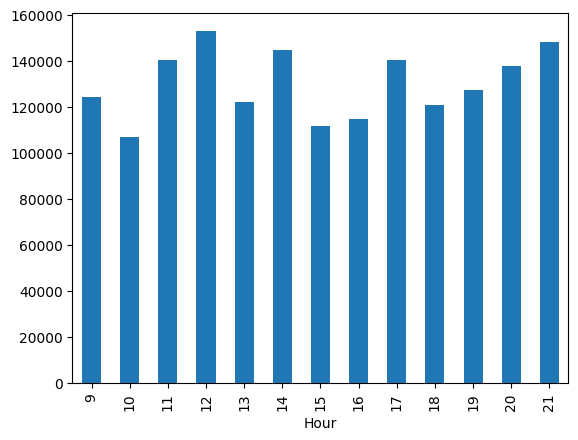

In [6]:
df["Hour"] = pd.to_datetime(df["Time_of_Purchase"]).dt.hour

hourly_sales = df.groupby("Hour")["Revenue"].sum()

hourly_sales.plot(kind="bar")

<Axes: ylabel='Revenue'>

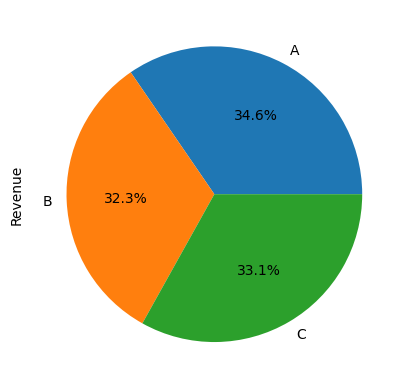

In [7]:
branch_sales = df.groupby("Branch")["Revenue"].sum()

branch_sales.plot(kind="pie", autopct='%1.1f%%')

<Axes: xlabel='Date'>

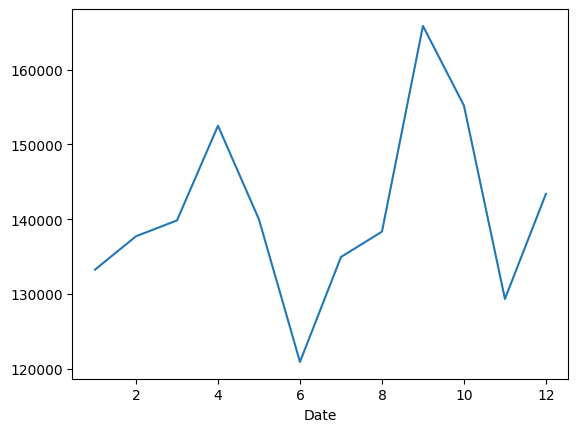

In [10]:
df["Date"] = pd.to_datetime(df["Date"])

monthly_sales = df.groupby(df["Date"].dt.month)["Revenue"].sum()

monthly_sales.plot()